# XGBoost — Baseline Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
DATA_DIR = Path("data")

X_train = pd.read_csv(
    DATA_DIR / "(experiment) X_train.csv",
    index_col=0,
    parse_dates=True
)

y_train = pd.read_csv(
    DATA_DIR / "(experiment) y_train.csv",
    index_col=0,
    parse_dates=True
)

X_test = pd.read_csv(
    DATA_DIR / "(experiment) X_test.csv",
    index_col=0,
    parse_dates=True
)

y_test = pd.read_csv(
    DATA_DIR / "(experiment) y_test.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training class distribution:
PCE_Regime
0             29
1             30
Name: count, dtype: int64

Testing class distribution:
PCE_Regime
0              8
1             10
Name: count, dtype: int64


## 1. Import XGBoost

In [4]:
# ============================================================
# XGBOOST CLASSIFICATION MODEL
# PCE Growth Regime Classification
# ============================================================

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 2. Build the baseline XGBoost pipeline

In [7]:
# ============================================================
# BUILD BASELINE XGBOOST PIPELINE
# ============================================================

# Setting baseline parameters

xgb_pipeline = Pipeline([
    
    # Handle missing values consistently
    ("imputer", SimpleImputer(strategy="median")),
    
    # Baseline XGBoost classifier
    ("xgb", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])
print(xgb_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
            

## 3. Train XGBoost

In [8]:
# ============================================================
# TRAIN XGBOOST
# ============================================================

xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

## 4. Generate test predictions

In [10]:
# ============================================================
# XGBOOST TEST PREDICTIONS
# ============================================================

xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]


xgb_predictions = pd.DataFrame({
    "Actual": y_test.squeeze(),
    "Predicted": xgb_pred,
    "Probability_Strong": xgb_prob
})

display(xgb_predictions)

# 0=Weak PCE Growth
# 1=Strong PCE Growth

,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,0.880236
2022-06-30,1,0,0.447245
2022-09-30,0,0,0.132976
2022-12-31,0,0,0.151688
2023-03-31,1,0,0.174379
2023-06-30,0,0,0.311883
2023-09-30,1,1,0.644282
2023-12-31,1,1,0.553929
2024-03-31,0,1,0.678971


## 5. Calculate performance metrics

In [11]:
# ============================================================
# XGBOOST PERFORMANCE METRICS
# ============================================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)


print("=" * 55)
print("XGBOOST MODEL PERFORMANCE")
print("=" * 55)

print(f"Accuracy:           {xgb_accuracy:.4f}")
print(f"Balanced Accuracy:  {xgb_balanced_accuracy:.4f}")
print(f"Precision:          {xgb_precision:.4f}")
print(f"Recall:             {xgb_recall:.4f}")
print(f"F1 Score:           {xgb_f1:.4f}")
print(f"ROC-AUC:            {xgb_roc_auc:.4f}")

XGBOOST MODEL PERFORMANCE
Accuracy:           0.5556
Balanced Accuracy:  0.5750
Precision:          0.6667
Recall:             0.4000
F1 Score:           0.5000
ROC-AUC:            0.6000


## 6. Classification report

In [12]:
# ============================================================
# XGBOOST CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Weak Growth",
            "Strong Growth"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Weak Growth       0.50      0.75      0.60         8
Strong Growth       0.67      0.40      0.50        10

     accuracy                           0.56        18
    macro avg       0.58      0.57      0.55        18
 weighted avg       0.59      0.56      0.54        18



## 7. Confusion matrix

In [13]:
# ============================================================
# XGBOOST CONFUSION MATRIX
# ============================================================

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print("XGBoost Confusion Matrix:")
print(xgb_cm)

XGBoost Confusion Matrix:
[[6 2]
 [6 4]]


$$
\begin{bmatrix}
TN=6 & FP=2 \\
FN=6 & TP=4
\end{bmatrix}
$$

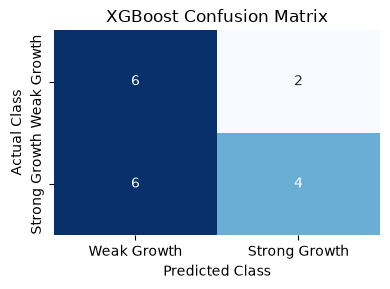

In [15]:
# ============================================================
# XGBOOST CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(4, 3))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Weak Growth",
        "Strong Growth"
    ],
    yticklabels=[
        "Weak Growth",
        "Strong Growth"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

## 8. Add XGBoost to the comparison table

In [17]:
# ============================================================
# XGBOOST RESULT TABLE
# ============================================================

xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy],
    "Balanced Accuracy": [xgb_balanced_accuracy],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "F1": [xgb_f1],
    "ROC-AUC": [xgb_roc_auc]
})

display(xgb_results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.5556,0.575,0.6667,0.4,0.5,0.6


| Metric            | **XGBoost** | Interpretation                                               |
| ----------------- | ----------: | ------------------------------------------------------------ |
| Accuracy          |  **0.5556** | 55.56% of test quarters were classified correctly            |
| Balanced Accuracy |  **0.5750** | Average performance across Weak and Strong classes was 57.5% |
| Precision         |  **0.6667** | When predicting Strong Growth, 66.67% were actually Strong   |
| Recall            |  **0.4000** | It identified 40% of the actual Strong-Growth quarters       |
| F1                |  **0.5000** | Moderate/weak balance between precision and recall           |
| ROC-AUC           |  **0.6000** | Best probability-ranking performance among the tested models |


### Interpretation: 

XGBoost tied Logistic Regression on the classification metrics but achieved a higher ROC-AUC (0.60 vs. 0.55), suggesting somewhat better ranking of Weak versus Strong Growth probabilities.

## 9. XGBoost feature importance

In [18]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

fitted_xgb = xgb_pipeline.named_steps["xgb"]

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": fitted_xgb.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(xgb_importance.head(15))

,Feature,Importance
0,Rental Income,0.080958
1,Delinquency Rate,0.056557
2,Exchange Rate,0.038534
3,Dividend Income,0.035926
4,Initial Jobless Claims,0.033219
5,Vehicle Sales,0.032738
6,House Price Index,0.027030
7,Self-employment Income,0.026465
8,Employment Rate,0.026276
9,Full-time Employment,0.025681


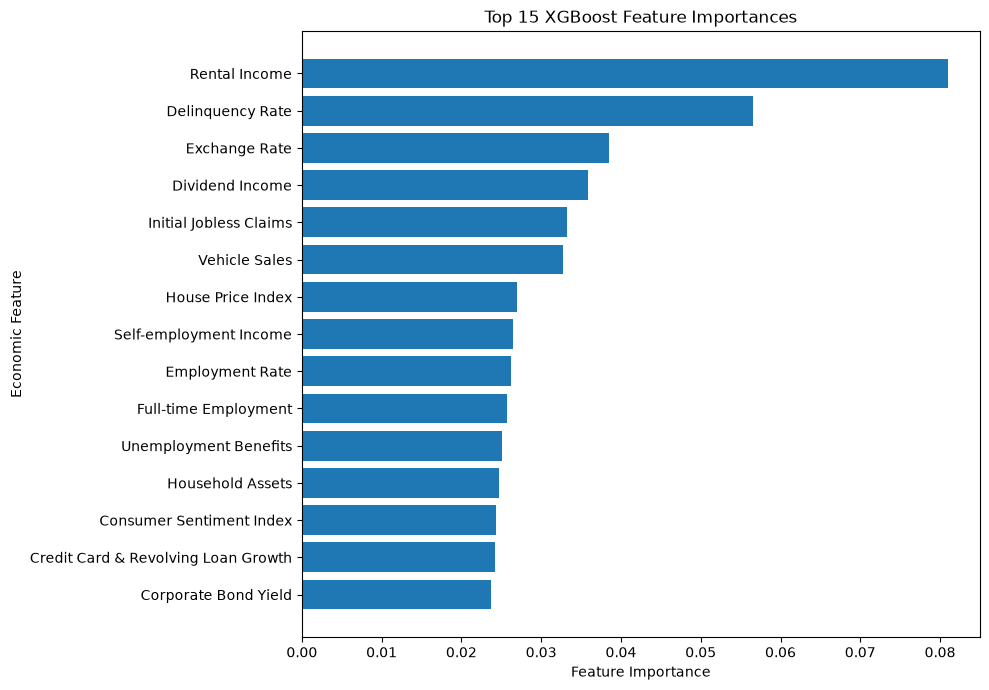

In [19]:
# ============================================================
# VISUALIZE XGBOOST FEATURE IMPORTANCE
# ============================================================

top_xgb_features = xgb_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_xgb_features["Feature"][::-1],
    top_xgb_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Economic Feature")

plt.title(
    "Top 15 XGBoost Feature Importances"
)

plt.tight_layout()
plt.show()

#### interpretation: 

These variables contributed relatively more to the fitted XGBoost tree ensemble under this particular training specification. They are not as economic causation. 

Compared with Random Forest, XGBoost asks: 

**Can sequential error correction uncover PCE regime structure that the previous models missed**? 

## NEXT --> Baseline model family comparison 

why the models are struggling: **small \(n\)/large \(p\)**, **redundant predictors**, **temporal distribution shift**, **unstable features**, and whether feature selection improves out-of-sample regime classification

small n: small attributes (predictors)\
large p : large probabilty problem 

### Conclusion: 

Logistic Regression and XGBoost currently provide the strongest balanced classification performance among the tested models, while **XGBoost produces the highest ROC-AUC**. However, both models remain weak classifiers overall.